### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import pandas as pd



In [2]:
# ground truth
gt_train_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='ground_truth_train', dtype={'pdfname': str, "gt_source": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
gt_train_df = pd.DataFrame(gt_train_rpts)
gt_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   pdfname         34 non-null     str  
 1   gt_source       34 non-null     str  
 2   ES_0_percent    34 non-null     bool 
 3   ES_100_percent  34 non-null     bool 
 4   ES_partial      34 non-null     bool 
 5   number_of_cats  34 non-null     int64
dtypes: bool(3), int64(1), str(2)
memory usage: 2.4 KB


In [3]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,5
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,8
4,CABEI_Green_Bond_Framework,manual,False,False,True,4
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6
7,CIFI_Green_Bond_Framework,manual,False,False,True,3
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2


In [4]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in gt_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
gt_train_df['ES_percent_true'] = ES_percent_true

In [5]:
gt_train_df

,pdfname,gt_source,ES_0_percent,ES_100_percent,ES_partial,number_of_cats,ES_percent_true
0,Climate_Bond_Framework_of_E1_SUBHOLDING_S_A__i...,alloc data table,False,True,False,0,ES 100%
1,Bci_Sustainable_Financing_Framework,manual,False,False,True,6,ES partial
2,"BTG_Pactual_Green,_Social_and_Sustainable_Fina...",manual,False,False,True,5,ES partial
3,BTG_Sustainable_Financing_Framework,manual,False,False,True,8,ES partial
4,CABEI_Green_Bond_Framework,manual,False,False,True,4,ES partial
5,CADU_GREEN_BOND_FRAMEWORK,manual,True,False,False,0,ES 0%
6,CAFs_GREEN_BOND_FRAMEWORK,manual,False,False,True,6,ES partial
7,CIFI_Green_Bond_Framework,manual,False,False,True,3,ES partial
8,EGE_Haina_Green_Securities_Framework,manual,False,True,False,0,ES 100%
9,FS_Green_Bond_Framework_-_July_2021,manual,False,False,True,2,ES partial


In [6]:
# pipeline predictions - V4 sim TH = 0.65
pred_train_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_2ndPass/pred_train_rpts_V4.csv')
pred_train_df = pd.DataFrame(pred_train_rpts)
pred_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [7]:
# pipeline predictions - V5 sim TH = 0.80
pred_train_rpts_v5 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_2ndPass/pred_train_rpts_V5.csv')
pred_train_df_v5 = pd.DataFrame(pred_train_rpts_v5)
pred_train_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [8]:
# pipeline predictions - V6 sim TH = 0.88 & cleanup TH 0.70
pred_train_rpts_v6 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_2ndPass/pred_train_rpts_V6.csv')
pred_train_df_v6 = pd.DataFrame(pred_train_rpts_v6)
pred_train_df_v6.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [9]:
# pipeline predictions - V7 sim TH = 0.97 & cleanup TH 0.77
pred_train_rpts_v7 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_2ndPass/pred_train_rpts_V7.csv')
pred_train_df_v7 = pd.DataFrame(pred_train_rpts_v7)
pred_train_df_v7.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [52]:
# pipeline predictions - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70
pred_train_rpts_v8 = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_2ndPass/pred_train_rpts_V8.csv')
pred_train_df_v8 = pd.DataFrame(pred_train_rpts_v8)
pred_train_df_v8.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34 non-null     int64  
 1   pdfname               34 non-null     str    
 2   nlp_path              34 non-null     str    
 3   language              34 non-null     str    
 4   similarity_threshold  34 non-null     float64
 5   cleanup_threshold     34 non-null     float64
 6   ES_0_percent          34 non-null     bool   
 7   ES_100_percent        34 non-null     bool   
 8   ES_partial            34 non-null     bool   
 9   number_of_cats        34 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 3.7 KB


In [10]:
# create y_pred based on ES percent cols - V4 sim TH = 0.65
ES_percent_pred = []
for r in pred_train_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df['ES_percent_pred'] = ES_percent_pred


In [11]:
# create y_pred based on ES percent cols - V5 sim TH = 0.80
ES_percent_pred = []
for r in pred_train_df_v5.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v5['ES_percent_pred'] = ES_percent_pred

In [12]:
# create y_pred based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_percent_pred = []
for r in pred_train_df_v6.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v6['ES_percent_pred'] = ES_percent_pred

In [ ]:
# create y_pred based on ES percent cols - V7 sim TH = 0.97 & cleanup TH 0.77
ES_percent_pred = []
for r in pred_train_df_v7.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v7['ES_percent_pred'] = ES_percent_pred

In [54]:
# create y_pred based on ES percent cols - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70
ES_percent_pred = []
for r in pred_train_df_v8.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_train_df_v8['ES_percent_pred'] = ES_percent_pred

In [14]:
# create a dataset containing results for confusion matrix - V4 sim TH = 0.65

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_train_df['pdfname']
conf_mtrx_df['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_train_df['nlp_path']
conf_mtrx_df['language'] = pred_train_df['language']
conf_mtrx_df['similarity_th'] = pred_train_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_train_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_train_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_train_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']


In [15]:
# create a dataset containing results for confusion matrix - V5 sim TH = 0.80

conf_mtrx_df_v5 = pd.DataFrame()

conf_mtrx_df_v5['pdfname'] = pred_train_df_v5['pdfname']
conf_mtrx_df_v5['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v5['nlp_path'] = pred_train_df_v5['nlp_path']
conf_mtrx_df_v5['language'] = pred_train_df_v5['language']
conf_mtrx_df_v5['similarity_th'] = pred_train_df_v5['similarity_threshold']
conf_mtrx_df_v5['cleanup_th'] = pred_train_df_v5['cleanup_threshold']
conf_mtrx_df_v5['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v5['ES_percent_pred'] = pred_train_df_v5['ES_percent_pred']
conf_mtrx_df_v5['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v5['num_cats_pred'] = pred_train_df_v5['number_of_cats']
conf_mtrx_df_v5['num_cats_diff'] = conf_mtrx_df_v5['num_cats_true'] - conf_mtrx_df_v5['num_cats_pred']

In [16]:
# create a dataset containing results for confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

conf_mtrx_df_v6 = pd.DataFrame()

conf_mtrx_df_v6['pdfname'] = pred_train_df_v6['pdfname']
conf_mtrx_df_v6['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v6['nlp_path'] = pred_train_df_v6['nlp_path']
conf_mtrx_df_v6['language'] = pred_train_df_v6['language']
conf_mtrx_df_v6['similarity_th'] = pred_train_df_v6['similarity_threshold']
conf_mtrx_df_v6['cleanup_th'] = pred_train_df_v6['cleanup_threshold']
conf_mtrx_df_v6['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v6['ES_percent_pred'] = pred_train_df_v6['ES_percent_pred']
conf_mtrx_df_v6['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v6['num_cats_pred'] = pred_train_df_v6['number_of_cats']
conf_mtrx_df_v6['num_cats_diff'] = conf_mtrx_df_v6['num_cats_true'] - conf_mtrx_df_v6['num_cats_pred']

In [ ]:
# create a dataset containing results for confusion matrix - V7 sim TH = 0.97 & cleanup TH 0.77

conf_mtrx_df_v7 = pd.DataFrame()

conf_mtrx_df_v7['pdfname'] = pred_train_df_v7['pdfname']
conf_mtrx_df_v7['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v7['nlp_path'] = pred_train_df_v7['nlp_path']
conf_mtrx_df_v7['language'] = pred_train_df_v7['language']
conf_mtrx_df_v7['similarity_th'] = pred_train_df_v7['similarity_threshold']
conf_mtrx_df_v7['cleanup_th'] = pred_train_df_v7['cleanup_threshold']
conf_mtrx_df_v7['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v7['ES_percent_pred'] = pred_train_df_v7['ES_percent_pred']
conf_mtrx_df_v7['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v7['num_cats_pred'] = pred_train_df_v7['number_of_cats']
conf_mtrx_df_v7['num_cats_diff'] = conf_mtrx_df_v7['num_cats_true'] - conf_mtrx_df_v7['num_cats_pred']

In [55]:
# create a dataset containing results for confusion matrix - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70

conf_mtrx_df_v8 = pd.DataFrame()

conf_mtrx_df_v8['pdfname'] = pred_train_df_v8['pdfname']
conf_mtrx_df_v8['gt_source'] = gt_train_df['gt_source']
conf_mtrx_df_v8['nlp_path'] = pred_train_df_v8['nlp_path']
conf_mtrx_df_v8['language'] = pred_train_df_v8['language']
conf_mtrx_df_v8['similarity_th'] = pred_train_df_v8['similarity_threshold']
conf_mtrx_df_v8['cleanup_th'] = pred_train_df_v8['cleanup_threshold']
conf_mtrx_df_v8['ES_percent_true'] = gt_train_df['ES_percent_true']
conf_mtrx_df_v8['ES_percent_pred'] = pred_train_df_v8['ES_percent_pred']
conf_mtrx_df_v8['num_cats_true'] = gt_train_df['number_of_cats']
conf_mtrx_df_v8['num_cats_pred'] = pred_train_df_v8['number_of_cats']
conf_mtrx_df_v8['num_cats_diff'] = conf_mtrx_df_v8['num_cats_true'] - conf_mtrx_df_v8['num_cats_pred']

In [18]:
# create ES Partial TP col based on ES percent cols - V4 sim TH = 0.65
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [19]:
# create ES Partial TP col based on ES percent cols - V5 sim TH = 0.80
ES_partial_True_Positives = []
for r in conf_mtrx_df_v5.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v5['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v5['ES_partial_True_Positives'].value_counts()
conf_mtrx_df_v5.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    34 non-null     str    
 1   gt_source                  34 non-null     str    
 2   nlp_path                   34 non-null     str    
 3   language                   34 non-null     str    
 4   similarity_th              34 non-null     float64
 5   cleanup_th                 34 non-null     float64
 6   ES_percent_true            34 non-null     str    
 7   ES_percent_pred            34 non-null     str    
 8   num_cats_true              34 non-null     int64  
 9   num_cats_pred              34 non-null     int64  
 10  num_cats_diff              34 non-null     int64  
 11  ES_partial_True_Positives  34 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 5.5 KB


In [20]:
# create ES Partial TP col based on ES percent cols - V6 sim TH = 0.88 & cleanup TH 0.70
ES_partial_True_Positives = []
for r in conf_mtrx_df_v6.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v6['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v6['ES_partial_True_Positives'].value_counts()


ES_partial_True_Positives
False    17
True     17
Name: count, dtype: int64

In [ ]:
# create ES Partial TP col based on ES percent cols - V7 sim TH = 0.97 & cleanup TH 0.77
ES_partial_True_Positives = []
for r in conf_mtrx_df_v7.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v7['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v7['ES_partial_True_Positives'].value_counts()

ES_partial_True_Positives
True     18
False    16
Name: count, dtype: int64

In [56]:
# create ES Partial TP col based on ES percent cols - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70
ES_partial_True_Positives = []
for r in conf_mtrx_df_v8.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df_v8['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df_v8['ES_partial_True_Positives'].value_counts()

ES_partial_True_Positives
False    17
True     17
Name: count, dtype: int64

In [22]:
# bring in data from eval - V4 sim TH = 0.65

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[30,  1],
        [ 2,  1]],

       [[22,  1],
        [ 8,  3]],

       [[ 4, 10],
        [ 2, 18]]])

In [23]:
# bring in data from eval - V5 sim TH = 0.80

y_true_v5 = conf_mtrx_df_v5['ES_percent_true']
y_pred_v5 = conf_mtrx_df_v5['ES_percent_pred']
labels_v5 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v5, y_pred_v5, labels=labels_v5)

array([[[28,  3],
        [ 0,  3]],

       [[23,  0],
        [ 7,  4]],

       [[ 7,  7],
        [ 3, 17]]])

In [24]:
# bring in data from eval - V6 sim TH = 0.88 & cleanup TH 0.70

y_true_v6 = conf_mtrx_df_v6['ES_percent_true']
y_pred_v6 = conf_mtrx_df_v6['ES_percent_pred']
labels_v6 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v6, y_pred_v6, labels=labels_v6)

array([[[28,  3],
        [ 0,  3]],

       [[23,  0],
        [ 6,  5]],

       [[ 8,  6],
        [ 3, 17]]])

In [ ]:
# bring in data from eval - V7 sim TH = 0.97 & cleanup TH 0.77

y_true_v7 = conf_mtrx_df_v7['ES_percent_true']
y_pred_v7 = conf_mtrx_df_v7['ES_percent_pred']
labels_v7 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v7, y_pred_v7, labels=labels_v7)

array([[[27,  4],
        [ 0,  3]],

       [[23,  0],
        [ 6,  5]],

       [[10,  4],
        [ 2, 18]]])

In [57]:
# bring in data from eval - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70

y_true_v8 = conf_mtrx_df_v8['ES_percent_true']
y_pred_v8 = conf_mtrx_df_v8['ES_percent_pred']
labels_v8 = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true_v8, y_pred_v8, labels=labels_v8)

array([[[28,  3],
        [ 0,  3]],

       [[23,  0],
        [ 5,  6]],

       [[ 9,  5],
        [ 3, 17]]])

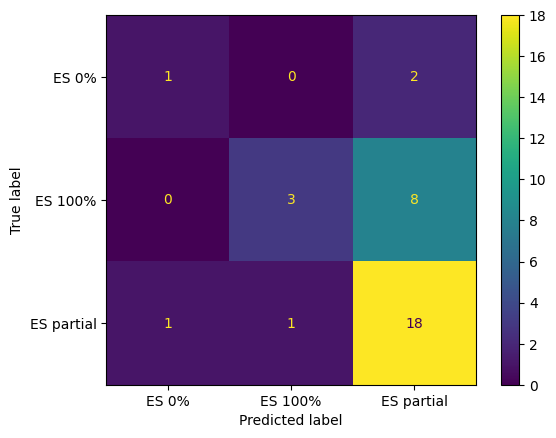

In [26]:
# display confusion matrix - V4 sim TH = 0.65

cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

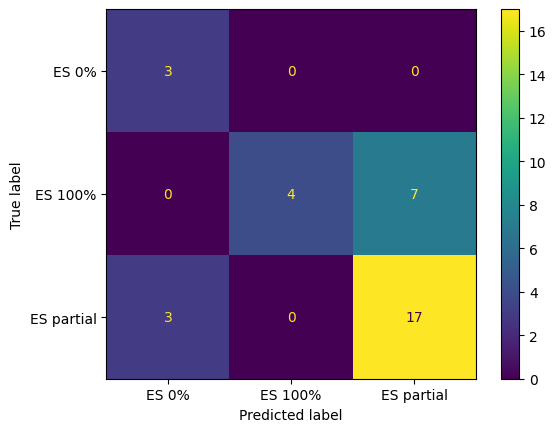

In [27]:
# display confusion matrix - V5 sim TH = 0.80

cm = multilabel_confusion_matrix(y_true_v5, y_pred_v5)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v5, y_pred_v5)
plt.show()


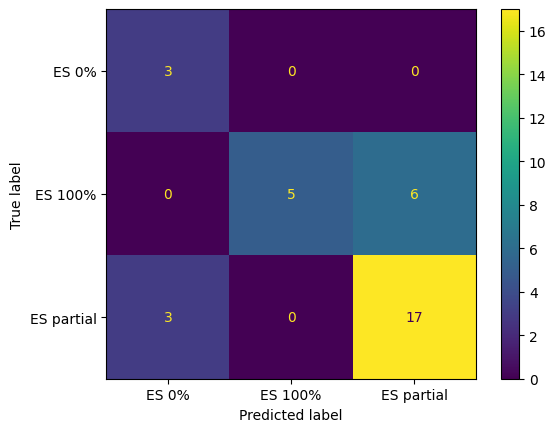

In [28]:
# display confusion matrix - V6 sim TH = 0.88 & cleanup TH 0.70

cm = multilabel_confusion_matrix(y_true_v6, y_pred_v6)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v6, y_pred_v6)
plt.show()

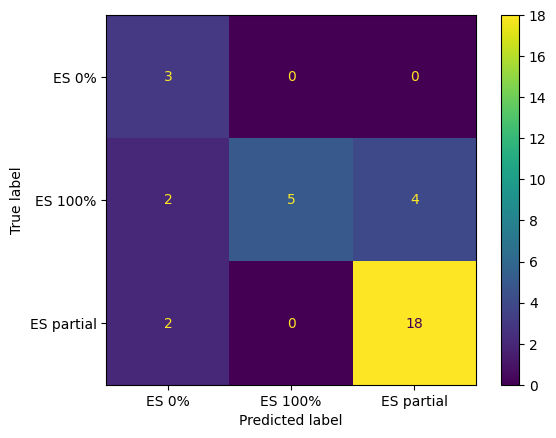

In [ ]:
# display confusion matrix - V7 sim TH = 0.97 & cleanup TH 0.77

cm = multilabel_confusion_matrix(y_true_v7, y_pred_v7)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v7, y_pred_v7)
plt.show()

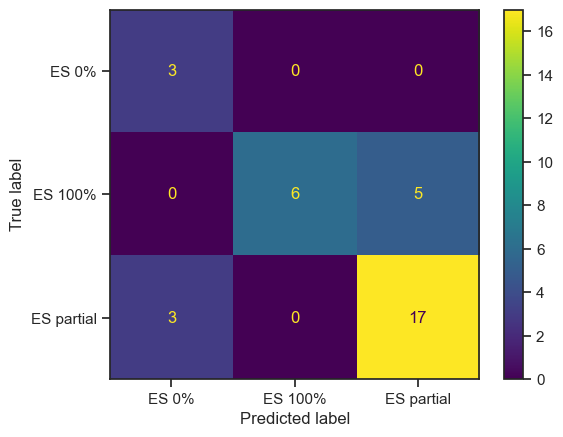

In [58]:
# display confusion matrix - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70

cm = multilabel_confusion_matrix(y_true_v8, y_pred_v8)
disp = ConfusionMatrixDisplay.from_predictions(y_true_v8, y_pred_v8)
plt.show()

In [443]:
# breakdown of ES 100% false negatives
# EGE a very good example of limitations of program
# Coop - problem with period in the ESML list. also problem with la and y in green buildings - limitation of program separates la from noun 
# inspect all 10 and cateogorise into limitations of prog and what that is vs fixable
# 10 falses - diagnose and would sim th by cat make any diff
trues = conf_mtrx_df_v8['ES_percent_true'] == 'ES 100%'
preds1 = conf_mtrx_df_v8['ES_percent_pred'] == 'ES partial'
preds2 = conf_mtrx_df_v8['ES_percent_pred'] == 'ES 0%'

ES_100_FNs = conf_mtrx_df_v8[trues & (preds1 | preds2)]
ES_100_FNs



,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
8,EGE_Haina_Green_Securities_Framework,manual,UOP_section_true,EN,0.97,0.77,ES 100%,ES partial,0,4,-4,False
11,Genneia_Green_Bond_Framework,manual,UOP_section_true,EN,0.97,0.77,ES 100%,ES partial,0,2,-2,False
16,ILAP_Green_Financing_Framework,manual,UOP_section_false,EN,0.97,0.77,ES 100%,ES partial,0,3,-3,False
27,Marco_de_Gestión_de_Bono_Verde,manual,UOP_section_false,ES,0.97,0.77,ES 100%,ES 0%,0,0,0,False
28,Marco_de_referencia_de_bono_verde_Coopeguanaca...,manual,UOP_section_true,ES,0.97,0.77,ES 100%,ES partial,0,2,-2,False
30,Nacional_Financiera_Green_Bond_MXN,manual,Table,ES,0.97,0.77,ES 100%,ES 0%,0,1,-1,False


In [440]:
# breakdown of ES partials FNs
trues = conf_mtrx_df_v8['ES_percent_true'] == 'ES partial'
preds = conf_mtrx_df_v8['ES_percent_pred'] == 'ES 0%'

ES_partial_FNs = conf_mtrx_df_v8[trues & preds]
ES_partial_FNs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
6,CAFs_GREEN_BOND_FRAMEWORK,manual,Table,EN,0.97,0.77,ES partial,ES 0%,6,3,3,False
15,Green_social_bond_framework_series_ad_ae_2019,alloc data table,Table,EN,0.97,0.77,ES partial,ES 0%,2,2,0,False


In [365]:
# breakdown of ES 0% FNs
trues = conf_mtrx_df_v7['ES_percent_true'] == 'ES 0%'
preds = conf_mtrx_df_v7['ES_percent_pred'] == 'ES partial'

ES_0_FNs = conf_mtrx_df_v7[trues & preds]
ES_0_FNs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives


#### root cause and fixes from V6 to V7
27	Marco_de_Gestión_de_Bono_Verde - found algorithmic errors in use of cats from table attributes - these have been corrected
31	Marco_de_Uso_de_Fondo_para_la_Emision_de_Bonos...	ground truth corrected - report covers two tranches, corrected to 1 tranche and green only (consistent with other corrections). probably due to table being over several pages not being handled accurately by the code - need to prove and see if a fix is possible
28	Marco_de_referencia_de_bono_verde_Coopeguanaca... even if fix from v5 is corrected (de and la assessment) still show up as partial de to limitation similar to EGE
8	EGE_Haina_Green_Securities_Framework - good example of limitations of prog
21	SONDA_S_A__GREEN_BOND_FRAMEWORK - alloc table data replaced with manual - overall gb but inclues re & ee. still has prog lim
15	Green_social_bond_framework_series_ad_ae_2019 prog lim in taking only LHCol of table
6	CAFs_GREEN_BOND_FRAMEWORK limitation of table going over page leading to missing rows but the ES 0% pred doesn't make sense - maybe this changes when we re-run
16	ILAP_Green_Financing_Framework - words from non UOP section
30	Nacional_Financiera_Green_Bond_MXN - limitation of prog - LHCol more granular
11	Genneia_Green_Bond_Framework - consider removing battery from CT list





In [30]:
# accuracy metrix - V4 sim TH = 0.65

as_frac = round(accuracy_score(y_true, y_pred),2)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)
print(as_frac, accuracy_score_num)

ck = round(cohen_kappa_score(y_true, y_pred),2)
print(ck)

f1 = round(f1_score(y_true, y_pred, average='macro'),2)
print(f1)

0.65 22.0
0.25
0.52


In [31]:
# accuracy metrix - V5 sim TH = 0.80

as_frac_v5 = round(accuracy_score(y_true_v5, y_pred_v5),2)
accuracy_score_num_v5 = accuracy_score(y_true_v5, y_pred_v5, normalize=False)
print(as_frac_v5, accuracy_score_num_v5)

ck_v5 = round(cohen_kappa_score(y_true_v5, y_pred_v5),2)
print(ck_v5)

f1_v5 = round(f1_score(y_true_v5, y_pred_v5, average='macro'),2)
print(f1_v5)

0.71 24.0
0.45
0.66


In [32]:
# accuracy metrix - V6 sim TH = 0.88 & cleanup TH 0.70

as_frac_v6 = round(accuracy_score(y_true_v6, y_pred_v6),2)
accuracy_score_num_v6 = accuracy_score(y_true_v6, y_pred_v6, normalize=False)
print(as_frac_v6, accuracy_score_num_v6)

ck_v6 = round(cohen_kappa_score(y_true_v6, y_pred_v6),2)
print(ck_v6)

f1_v6 = round(f1_score(y_true_v6, y_pred_v6, average='macro'),2)
print(f1_v6)

0.74 25.0
0.51
0.69


In [ ]:
# accuracy metrix - V7 sim TH = 0.97 & cleanup TH 0.77

as_frac_v7 = round(accuracy_score(y_true_v7, y_pred_v7),2)
accuracy_score_num_v7 = accuracy_score(y_true_v7, y_pred_v7, normalize=False)
print(as_frac_v7, accuracy_score_num_v7)

ck_v7 = round(cohen_kappa_score(y_true_v7, y_pred_v7),2)
print(ck_v7)

f1_v7 = round(f1_score(y_true_v7, y_pred_v7, average='macro'),2)
print(f1_v7)

0.76 26.0
0.57
0.69


In [59]:
# accuracy metrix - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70

as_frac_v8 = round(accuracy_score(y_true_v8, y_pred_v8),2)
accuracy_score_num_v8 = accuracy_score(y_true_v8, y_pred_v8, normalize=False)
print(as_frac_v8, accuracy_score_num_v8)

ck_v8 = round(cohen_kappa_score(y_true_v8, y_pred_v8),2)
print(ck_v8)

f1_v8 = round(f1_score(y_true_v8, y_pred_v8, average='macro'),2)
print(f1_v8)

0.76 26.0
0.57
0.73


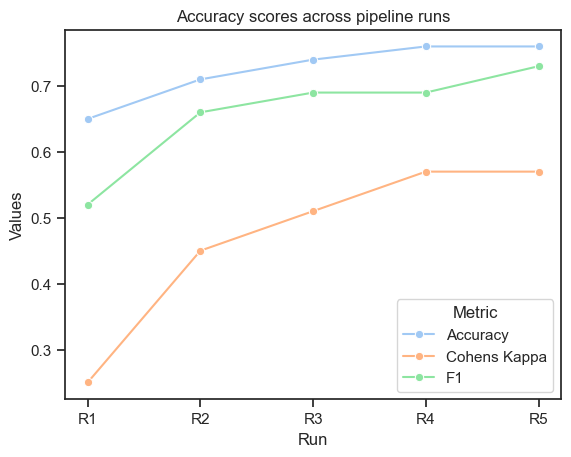

In [60]:
# line plot the accuracy results
#fig, ax = plt.subplots
accuracy_measures = {'Run': ['R1', 'R1','R1', 'R2', 'R2', 'R2',
                             'R3', 'R3', 'R3', 'R4', 'R4', 'R4', 'R5', 'R5', 'R5'],
                    'Metric': ['Accuracy', 'Cohens Kappa' , 'F1' , 'Accuracy', 'Cohens Kappa' , 'F1',
                               'Accuracy', 'Cohens Kappa' , 'F1' , 'Accuracy', 'Cohens Kappa' , 'F1',
                               'Accuracy', 'Cohens Kappa' , 'F1'],
                    'Values': [as_frac, ck, f1, as_frac_v5, ck_v5, f1_v5, 
                               as_frac_v6, ck_v6, f1_v6, as_frac_v7, ck_v7, f1_v7,
                               as_frac_v8, ck_v8, f1_v8]}
acc_meas_df = pd.DataFrame(accuracy_measures)
sns.set_theme(style='ticks', palette = 'pastel')
sns.lineplot(data = acc_meas_df, x = 'Run', y = 'Values', hue= 'Metric', marker = 'o')

plt.title('Accuracy scores across pipeline runs')
plt.show()


In [35]:
# create a dataset containing results for boxplots - V4 sim TH = 0.65

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 18 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    18 non-null     str    
 1   gt_source                  18 non-null     str    
 2   nlp_path                   18 non-null     str    
 3   language                   18 non-null     str    
 4   similarity_th              18 non-null     float64
 5   cleanup_th                 18 non-null     float64
 6   ES_percent_true            18 non-null     str    
 7   ES_percent_pred            18 non-null     str    
 8   num_cats_true              18 non-null     int64  
 9   num_cats_pred              18 non-null     int64  
 10  num_cats_diff              18 non-null     int64  
 11  ES_partial_True_Positives  18 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 3.0 KB


In [36]:
# create a dataset containing results for boxplots - V5 sim TH = 0.80

boxplot_df_v5 = conf_mtrx_df_v5.query("ES_partial_True_Positives == True")
boxplot_df_v5.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [37]:
# create a dataset containing results for boxplots - V6 sim TH = 0.88 & cleanup TH 0.70

boxplot_df_v6 = conf_mtrx_df_v6.query("ES_partial_True_Positives == True")
boxplot_df_v6.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


In [ ]:
# create a dataset containing results for boxplots - V7 sim TH = 0.97 & cleanup TH 0.77

boxplot_df_v7 = conf_mtrx_df_v7.query("ES_partial_True_Positives == True")
boxplot_df_v7.info()

<class 'pandas.DataFrame'>
Index: 18 entries, 1 to 31
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    18 non-null     str    
 1   gt_source                  18 non-null     str    
 2   nlp_path                   18 non-null     str    
 3   language                   18 non-null     str    
 4   similarity_th              18 non-null     float64
 5   cleanup_th                 18 non-null     float64
 6   ES_percent_true            18 non-null     str    
 7   ES_percent_pred            18 non-null     str    
 8   num_cats_true              18 non-null     int64  
 9   num_cats_pred              18 non-null     int64  
 10  num_cats_diff              18 non-null     int64  
 11  ES_partial_True_Positives  18 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 3.1 KB


In [61]:
# create a dataset containing results for boxplots - V8 EN .97 & .77, ES .8 & .65, PT .88 & .70

boxplot_df_v8 = conf_mtrx_df_v8.query("ES_partial_True_Positives == True")
boxplot_df_v8.info()

<class 'pandas.DataFrame'>
Index: 17 entries, 1 to 29
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    17 non-null     str    
 1   gt_source                  17 non-null     str    
 2   nlp_path                   17 non-null     str    
 3   language                   17 non-null     str    
 4   similarity_th              17 non-null     float64
 5   cleanup_th                 17 non-null     float64
 6   ES_percent_true            17 non-null     str    
 7   ES_percent_pred            17 non-null     str    
 8   num_cats_true              17 non-null     int64  
 9   num_cats_pred              17 non-null     int64  
 10  num_cats_diff              17 non-null     int64  
 11  ES_partial_True_Positives  17 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.9 KB


<Axes: xlabel='num_cats_diff'>

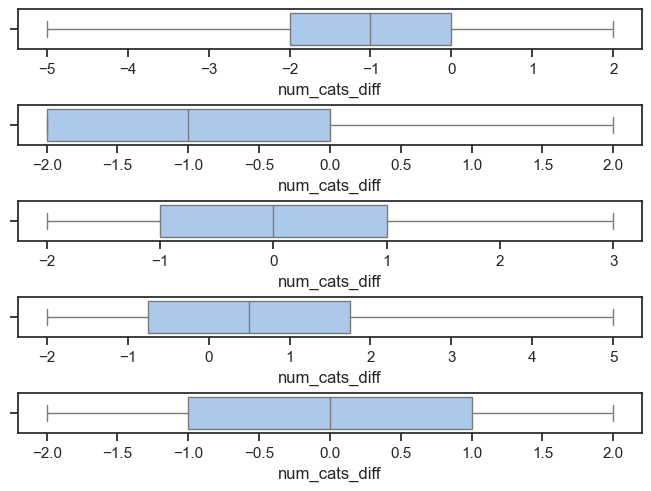

In [62]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(5,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], ax=axes[2])
sns.boxplot(x=boxplot_df_v7['num_cats_diff'], ax=axes[3])
sns.boxplot(x=boxplot_df_v8['num_cats_diff'], ax=axes[4])


<Axes: xlabel='num_cats_diff', ylabel='language'>

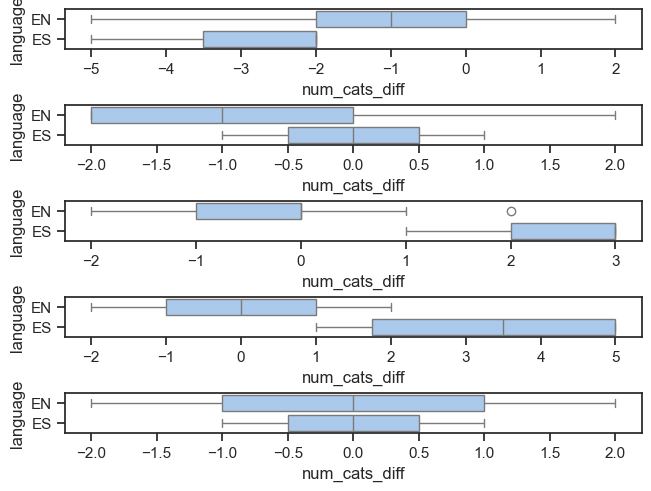

In [63]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(5,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['language'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['language'], ax=axes[2])
sns.boxplot(x=boxplot_df_v7['num_cats_diff'], y = boxplot_df_v7['language'], ax=axes[3])
sns.boxplot(x=boxplot_df_v8['num_cats_diff'], y = boxplot_df_v8['language'], ax=axes[4])


<Axes: xlabel='num_cats_diff', ylabel='nlp_path'>

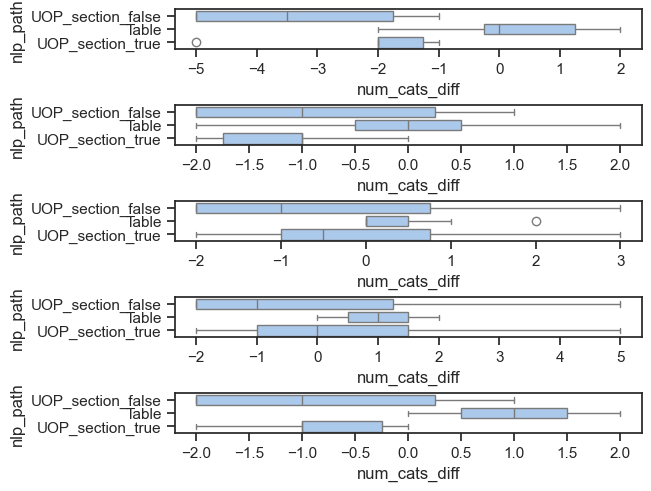

In [64]:
# boxplots of diff in number of cats - V4 sim TH = 0.65, V5 sim = 0.80 and V6 sim TH = 0.88 & cleanup TH 0.70

fig, axes = plt.subplots(5,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[0])
sns.boxplot(x=boxplot_df_v5['num_cats_diff'], y = boxplot_df_v5['nlp_path'], ax=axes[1])
sns.boxplot(x=boxplot_df_v6['num_cats_diff'], y = boxplot_df_v6['nlp_path'], ax=axes[2])
sns.boxplot(x=boxplot_df_v7['num_cats_diff'], y = boxplot_df_v7['nlp_path'], ax=axes[3])
sns.boxplot(x=boxplot_df_v8['num_cats_diff'], y = boxplot_df_v8['nlp_path'], ax=axes[4])

In [66]:
std = boxplot_df.describe().loc['std', 'num_cats_diff']
std_v5 = boxplot_df_v5.describe().loc['std', 'num_cats_diff']
std_v6 = boxplot_df_v6.describe().loc['std', 'num_cats_diff']
std_v7 = boxplot_df_v7.describe().loc['std', 'num_cats_diff']
std_v8 = boxplot_df_v8.describe().loc['std', 'num_cats_diff']


std_devn = {'Run': ['R1', 'R2', 'R3','R4', 'R5'],
            'Values': [std, std_v5, std_v6, std_v7, std_v8]}
std_dev_df = pd.DataFrame(std_devn)

cohens_kappa = {'Run': ['R1', 'R2', 'R3','R4', 'R5'],
                    'Values': [ck, ck_v5, ck_v6, ck_v7, ck_v8]}
cohens_kap_df = pd.DataFrame(cohens_kappa)

f1_score = {'Run': ['R1', 'R2', 'R3','R4', 'R5'],
                    'Values': [f1, f1_v5, f1_v6, f1_v7, f1_v8]}
f1_score_df = pd.DataFrame(f1_score)



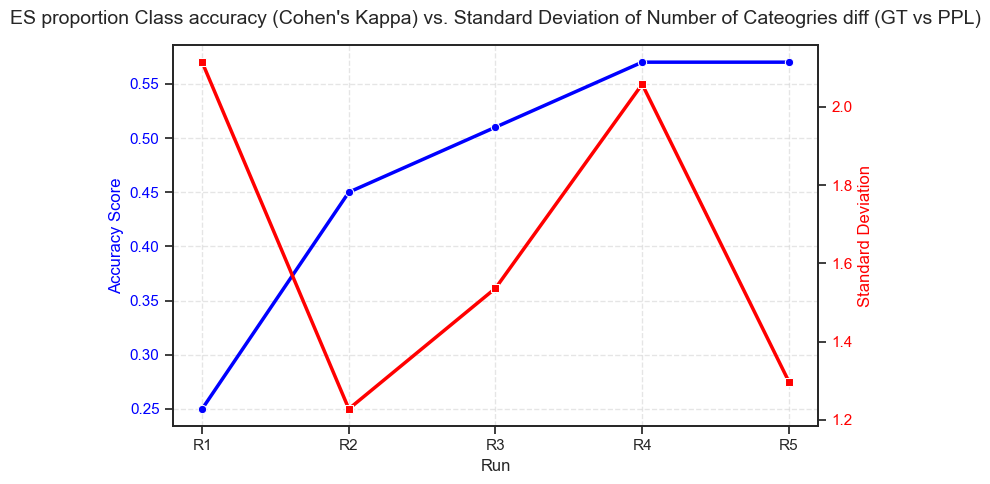

In [67]:
# line plot the cohens kappa and std devn results
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=cohens_kap_df,
    x="Run",
    y="Values",
    marker="o",
    color="blue",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("Accuracy Score", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_title(
    "ES proportion Class accuracy (Cohen's Kappa) vs. Standard Deviation of Number of Cateogries diff (GT vs PPL)", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=std_dev_df,
    x="Run",
    y="Values",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("Standard Deviation", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()


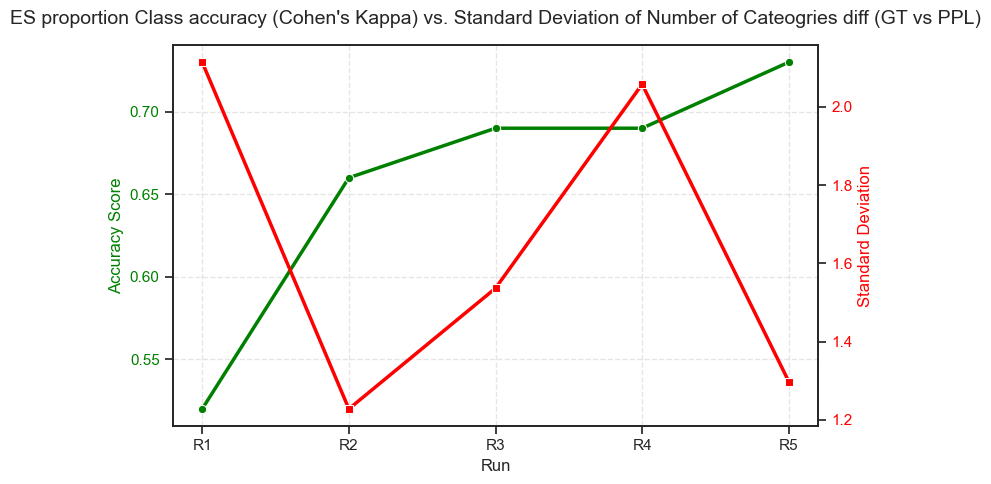

In [68]:
# line plot the f1 score and std devn results
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=f1_score_df,
    x="Run",
    y="Values",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("Accuracy Score", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "ES proportion Class accuracy (Cohen's Kappa) vs. Standard Deviation of Number of Cateogries diff (GT vs PPL)", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=std_dev_df,
    x="Run",
    y="Values",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("Standard Deviation", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

In [14]:
# similarity Scores for mapping
simScoreMap = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='simScoreMap', dtype={'run': str, "all ex RE median": float, "all ex RE count": int, "RE UOP median": float, "RE UOP count": int, "EE UOP median": float, "EE UOP count": int, "RE tbl median": float, "RE tbl count": int, "CT UOP median": float, "CT UOP count": int})
simScoreMapdf = pd.DataFrame(simScoreMap)
simScoreMapdf

,Run,all ex RE median,all ex RE count,RE UOP median,RE UOP count,EE UOP median,EE UOP count,RE tbl median,RE tbl count,CT UOP median,CT UOP count
0,R1,0.7338,38,0.6964,283,0.6745,23,0.7073,19,0.7293,66
1,R2,0.7338,38,0.9007,38,0.9156,2,0.9305,8,0.8782,24
2,R3,0.7977,28,1.0000,25,1.0000,1,0.9762,4,1.0000,11
3,R4,0.8469,15,1.0000,21,1.0000,1,1.0000,2,1.0000,9
4,R5,0.8143,24,0.9737,26,1.0000,1,0.9085,7,1.0000,11


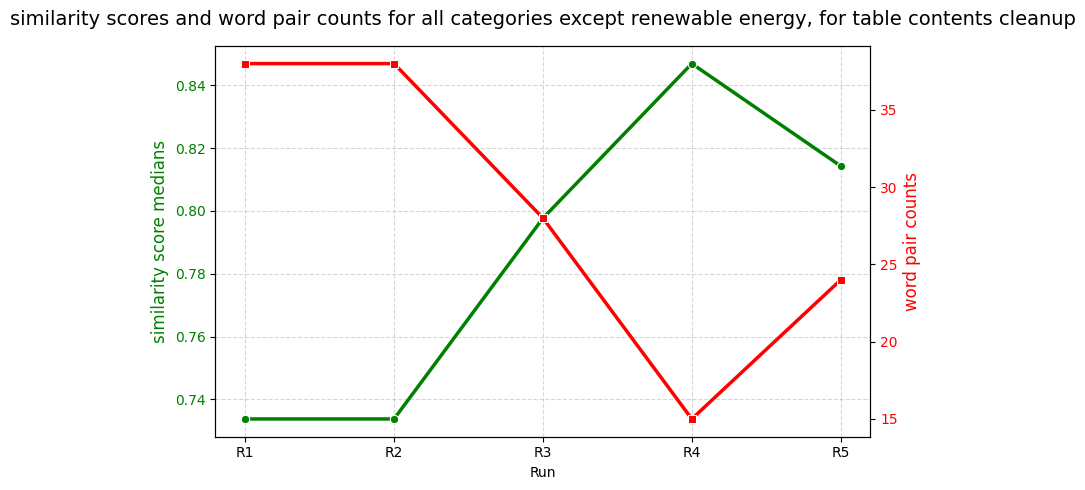

In [11]:
# line plot the simScore medians and above threshold word pair counts for three dictionaries
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="all ex RE median",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("similarity score medians", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "similarity scores and word pair counts for all categories except renewable energy, for table contents cleanup", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="all ex RE count",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("word pair counts", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

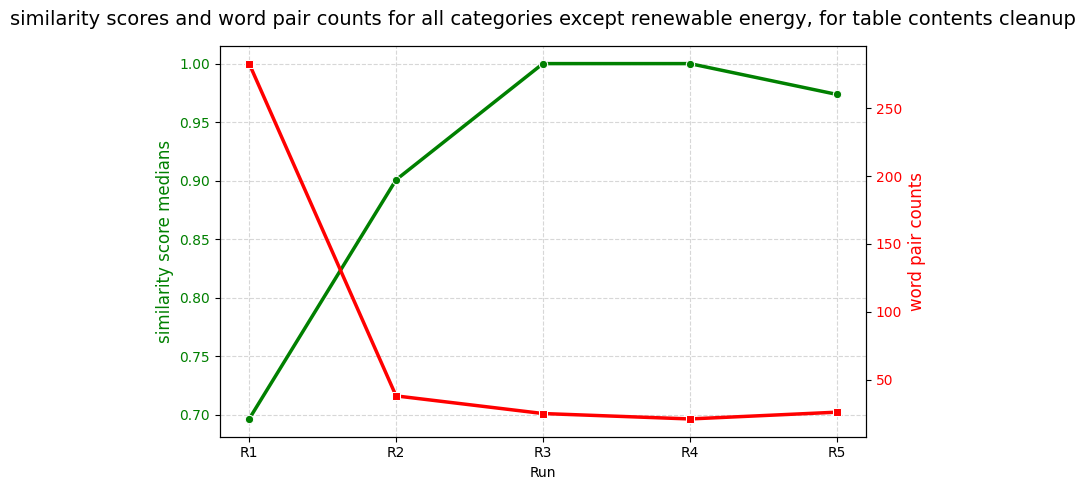

In [12]:
# line plot the simScore medians and above threshold word pair counts for three dictionaries
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="RE UOP median",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("similarity score medians", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "similarity scores and word pair counts for all categories except renewable energy, for table contents cleanup", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="RE UOP count",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("word pair counts", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

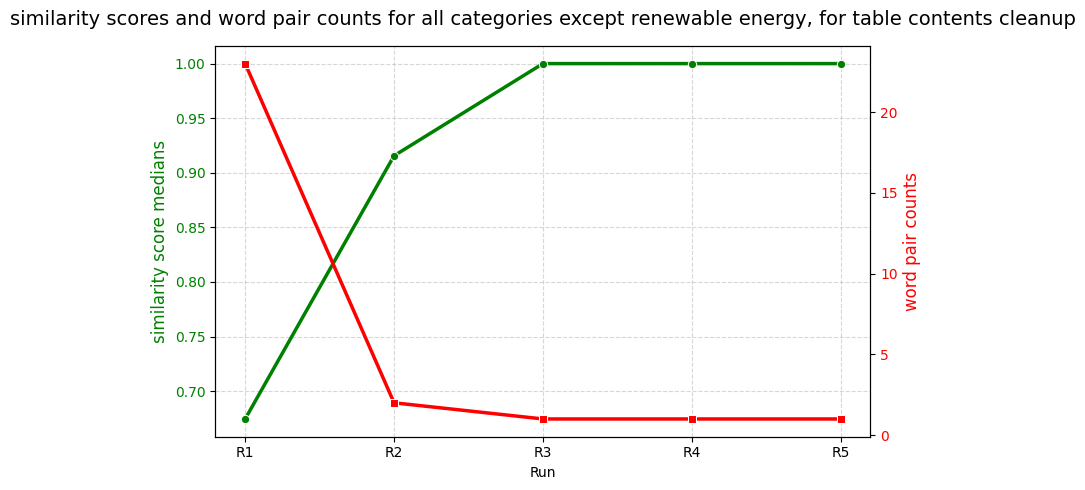

In [13]:
# line plot the simScore medians and above threshold word pair counts for three dictionaries
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="EE UOP median",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("similarity score medians", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "similarity scores and word pair counts for all categories except renewable energy, for table contents cleanup", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="EE UOP count",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("word pair counts", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

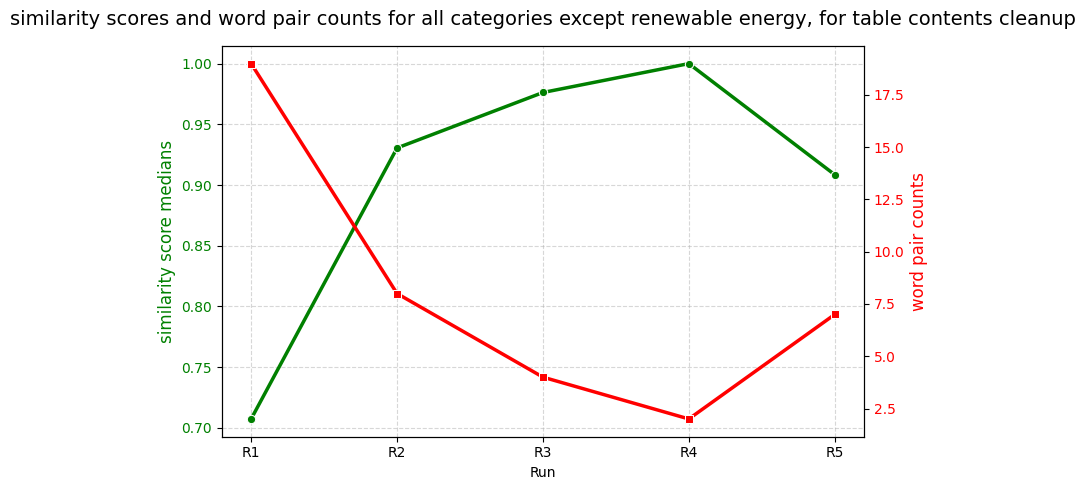

In [16]:
# line plot the simScore medians and above threshold word pair counts for three dictionaries
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="RE tbl median",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("similarity score medians", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "similarity scores and word pair counts for all categories except renewable energy, for table contents cleanup", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="RE tbl count",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("word pair counts", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

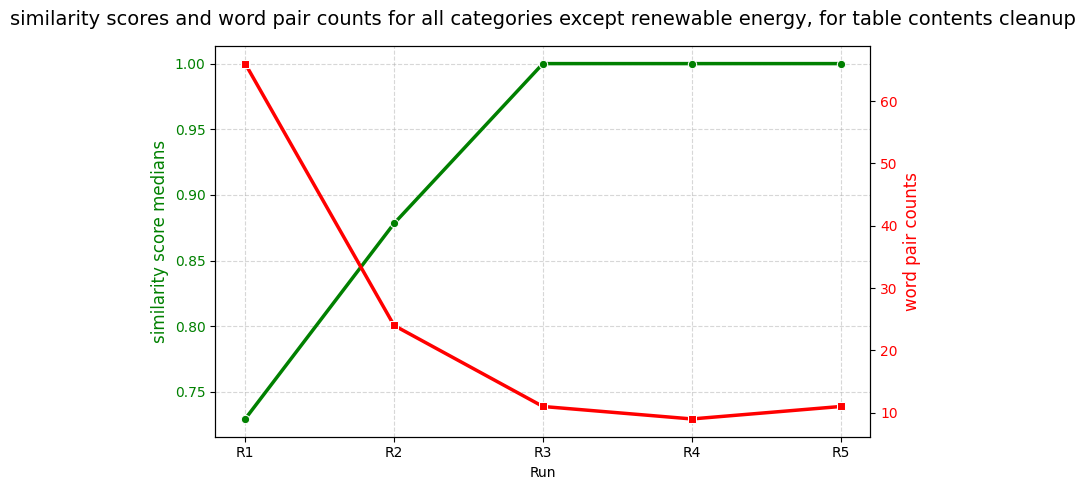

In [17]:
# line plot the simScore medians and above threshold word pair counts for three dictionaries
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="CT UOP median",
    marker="o",
    color="green",
    linewidth=2.5,
    ax=ax1,
)
ax1.set_ylabel("similarity score medians", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_title(
    "similarity scores and word pair counts for all categories except renewable energy, for table contents cleanup", 
    fontsize=14, pad=15)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

sns.lineplot(
    data=simScoreMapdf,
    x="Run",
    y="CT UOP count",
    marker="s",
    color="red",
    linewidth=2.5,
    ax=ax2,
)
ax2.set_ylabel("word pair counts", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()